### 运行结果

In [ ]:
import os
from analysis.tree_results_analysis import(
    load_block_parquets,
    analyze_feature_importance,
    analyze_predictions,
    analyze_metrics,
    load_importance_blocks,
    detect_importance_columns,
    plot_importance_heatmap,
    plot_feature_importance_lines,
)
from analysis.evals import plot_5min_metrics_from_dict
from analysis.plots import plot_pred_vs_true_time, plot_pred_true_scatter

DAY_RESULT_DIR = "saved_data/lgbm_rolling_results/2025-10-01"

IMPORTANCE_DIR = os.path.join(DAY_RESULT_DIR, "importance_blocks")
PREDICTION_DIR = os.path.join(DAY_RESULT_DIR, "prediction_blocks")
METRIC_DIR = os.path.join(DAY_RESULT_DIR, "metric_blocks")

#### Feature Importance 分析

[INFO] loaded 52 files from saved_data/lgbm_rolling_results/2025-10-01/importance_blocks, rows=2444
[WARN] directory not found: saved_data/lgbm_rolling_results/2025-10-01/prediction_blocks
[INFO] loaded 52 files from saved_data/lgbm_rolling_results/2025-10-01/metric_blocks, rows=52

===== Top features by mean gain =====
shape: (20, 6)
┌─────────────────────────────┬──────────────┬───────────────┬──────────┬─────────────┬────────────┐
│ feature                     ┆ gain_mean    ┆ gain_std      ┆ n_blocks ┆ split_mean  ┆ split_std  │
│ ---                         ┆ ---          ┆ ---           ┆ ---      ┆ ---         ┆ ---        │
│ str                         ┆ f64          ┆ f64           ┆ u32      ┆ f64         ┆ f64        │
╞═════════════════════════════╪══════════════╪═══════════════╪══════════╪═════════════╪════════════╡
│ vol_10m_lag0                ┆ 1.3765e7     ┆ 1.6493e7      ┆ 52       ┆ 1132.865385 ┆ 85.609471  │
│ vol_5m_lag0_time_nn5_mean   ┆ 3.9759e6     ┆ 6.4662e6  

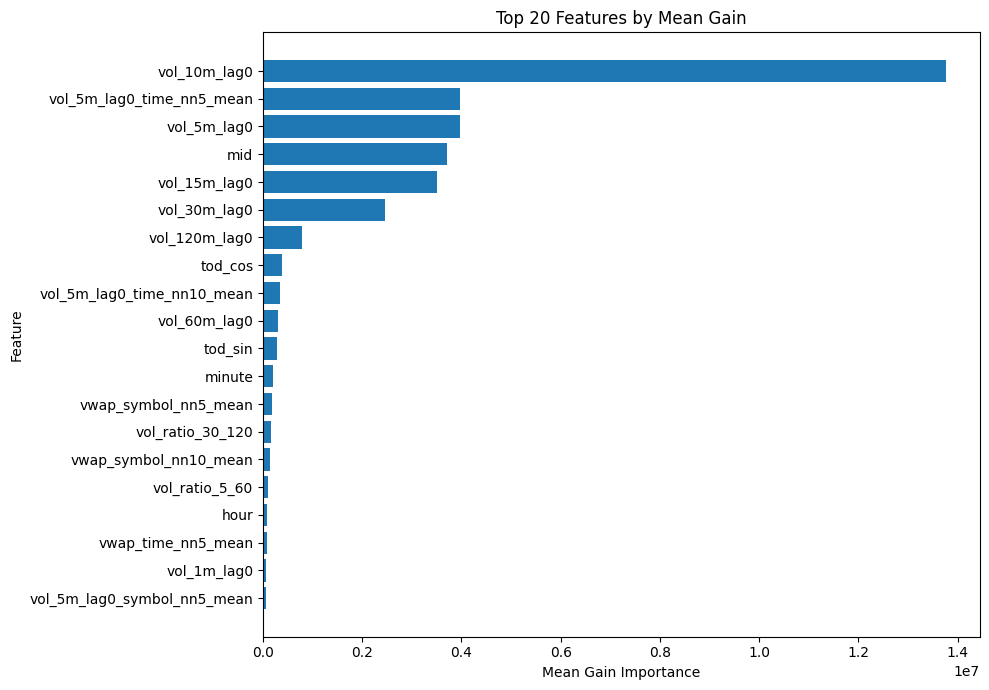


===== Top features by mean split =====
shape: (20, 6)
┌───────────────────────┬───────────────┬───────────────┬──────────┬─────────────┬────────────┐
│ feature               ┆ gain_mean     ┆ gain_std      ┆ n_blocks ┆ split_mean  ┆ split_std  │
│ ---                   ┆ ---           ┆ ---           ┆ ---      ┆ ---         ┆ ---        │
│ str                   ┆ f64           ┆ f64           ┆ u32      ┆ f64         ┆ f64        │
╞═══════════════════════╪═══════════════╪═══════════════╪══════════╪═════════════╪════════════╡
│ minute                ┆ 192717.295168 ┆ 117996.876569 ┆ 52       ┆ 2582.846154 ┆ 186.193067 │
│ tod_sin               ┆ 288759.476334 ┆ 225095.127387 ┆ 52       ┆ 2329.596154 ┆ 270.991445 │
│ tod_cos               ┆ 382600.154575 ┆ 286649.754067 ┆ 52       ┆ 2062.461538 ┆ 261.070831 │
│ vol_ratio_30_120      ┆ 167119.319886 ┆ 90359.738104  ┆ 52       ┆ 1872.519231 ┆ 97.837899  │
│ vol_120m_lag0         ┆ 782973.899819 ┆ 1.0216e6      ┆ 52       ┆ 1365.5      

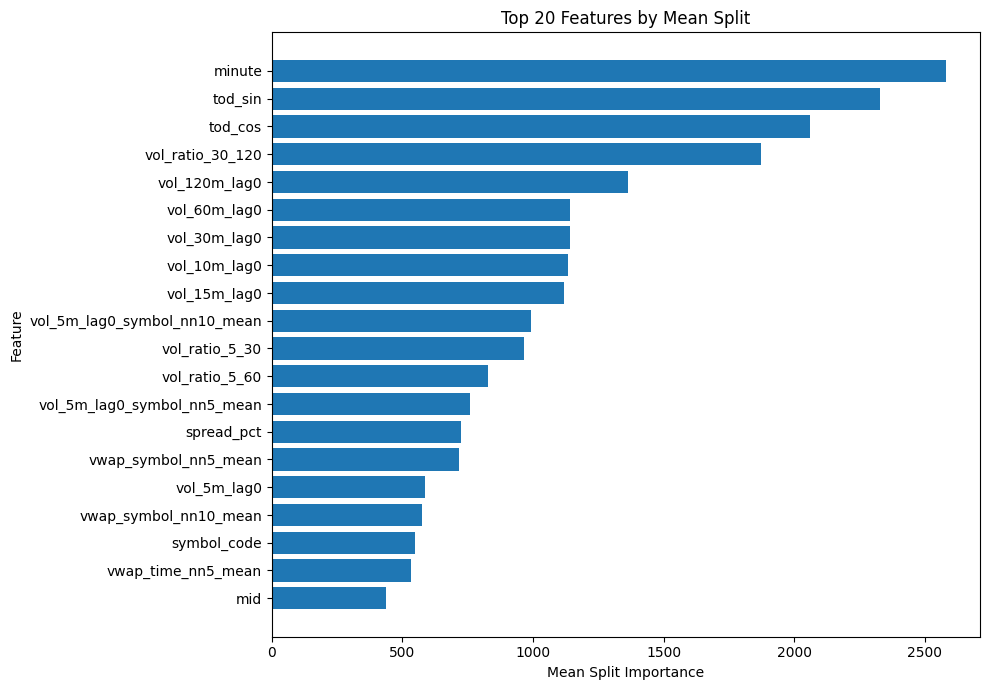

[WARN] no prediction data

===== Metric dataframe =====
shape: (52, 9)
┌────────────────┬───────────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬────────┐
│ test_file      ┆ block_name    ┆ n_train  ┆ n_test ┆ … ┆ mae      ┆ corr     ┆ qlike    ┆ n      │
│ ---            ┆ ---           ┆ ---      ┆ ---    ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---    │
│ str            ┆ str           ┆ i64      ┆ i64    ┆   ┆ f64      ┆ f64      ┆ f64      ┆ i64    │
╞════════════════╪═══════════════╪══════════╪════════╪═══╪══════════╪══════════╪══════════╪════════╡
│ 2025-10-01_06- ┆ 2025-10-01_06 ┆ 20520000 ┆ 570000 ┆ … ┆ 0.073429 ┆ 0.989823 ┆ 0.162575 ┆ 570000 │
│ 15-00.parquet  ┆ -15-00        ┆          ┆        ┆   ┆          ┆          ┆          ┆        │
│ 2025-10-01_06- ┆ 2025-10-01_06 ┆ 20520000 ┆ 570000 ┆ … ┆ 0.090258 ┆ 0.973061 ┆ 0.211333 ┆ 570000 │
│ 20-00.parquet  ┆ -20-00        ┆          ┆        ┆   ┆          ┆          ┆          ┆        │
│ 2025-10-01_06- ┆ 2

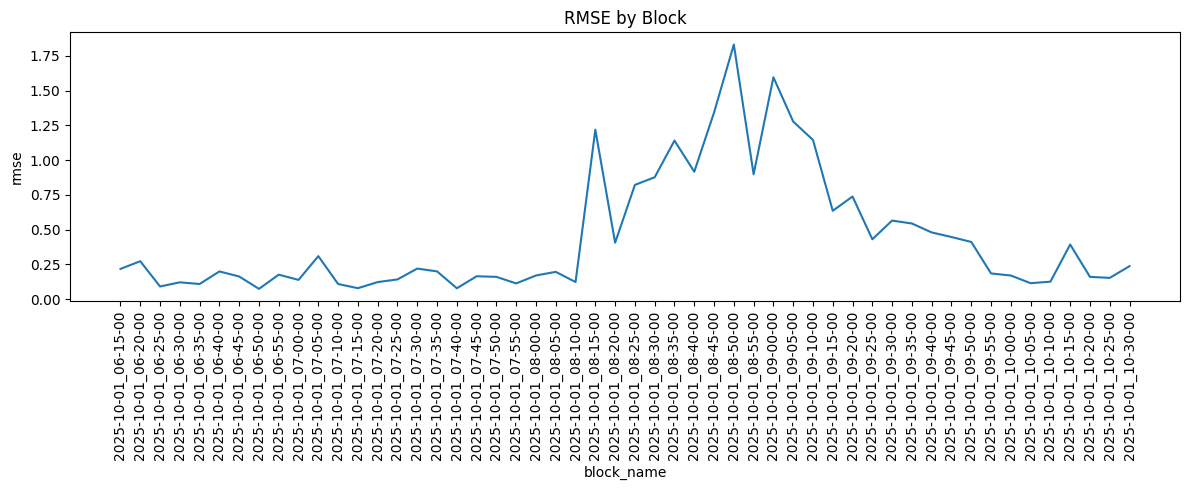

In [6]:
imp_df = load_block_parquets(IMPORTANCE_DIR)
pred_df = load_block_parquets(PREDICTION_DIR)
metric_df = load_block_parquets(METRIC_DIR)

imp_mean = analyze_feature_importance(imp_df, top_k=20)
pred_out = analyze_predictions(pred_df, top_k=20)
analyze_metrics(metric_df)

[INFO] loaded 52 block files, shape=(2444, 5)
[INFO] columns: ['test_file', 'block_name', 'feature', 'importance_gain', 'importance_split']
feature_col = feature
gain_col    = importance_gain
split_col   = importance_split


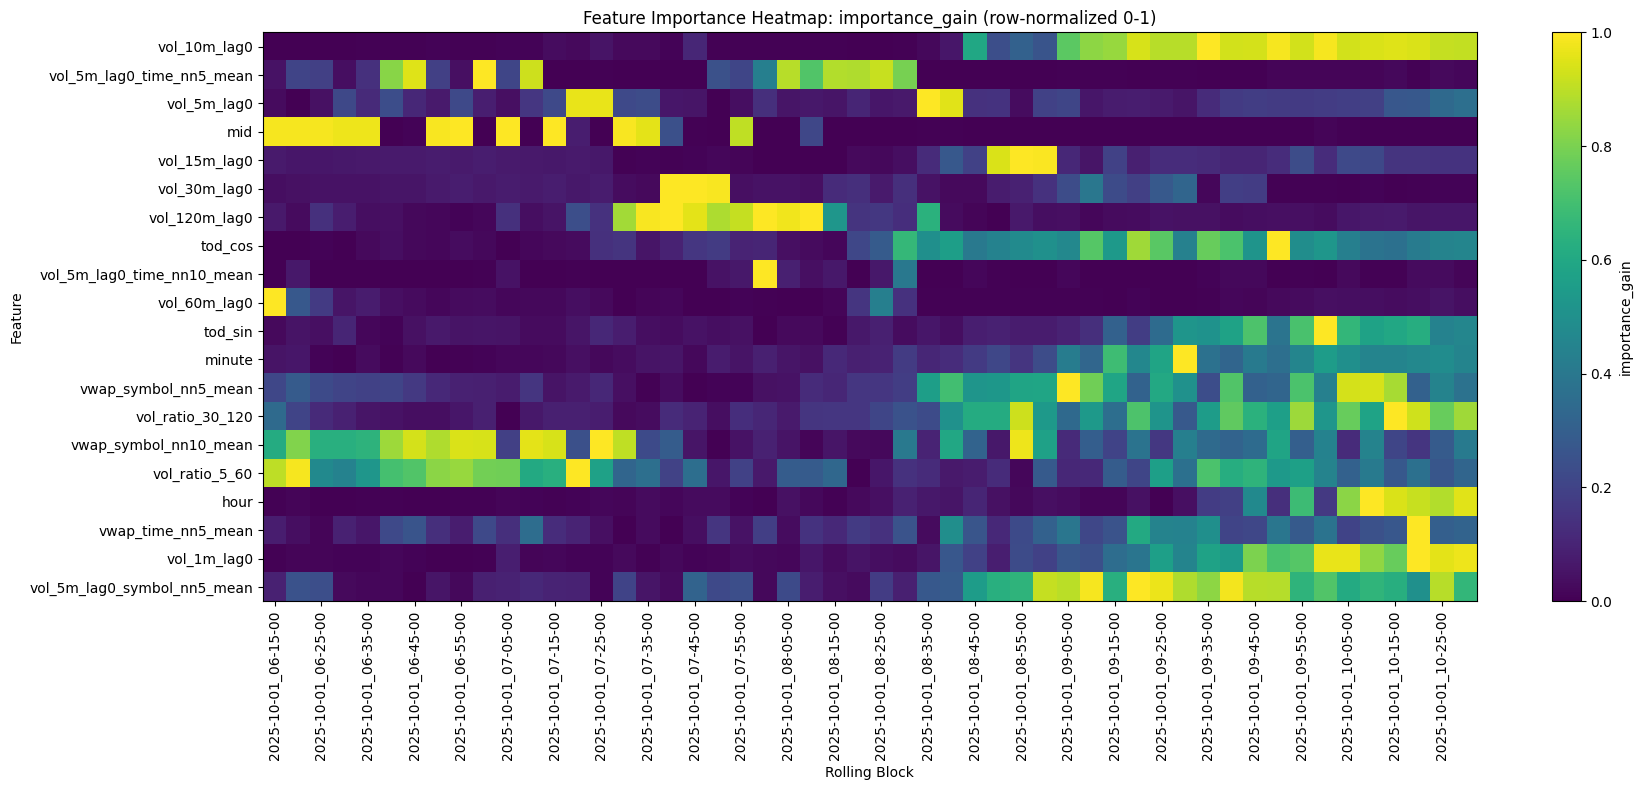

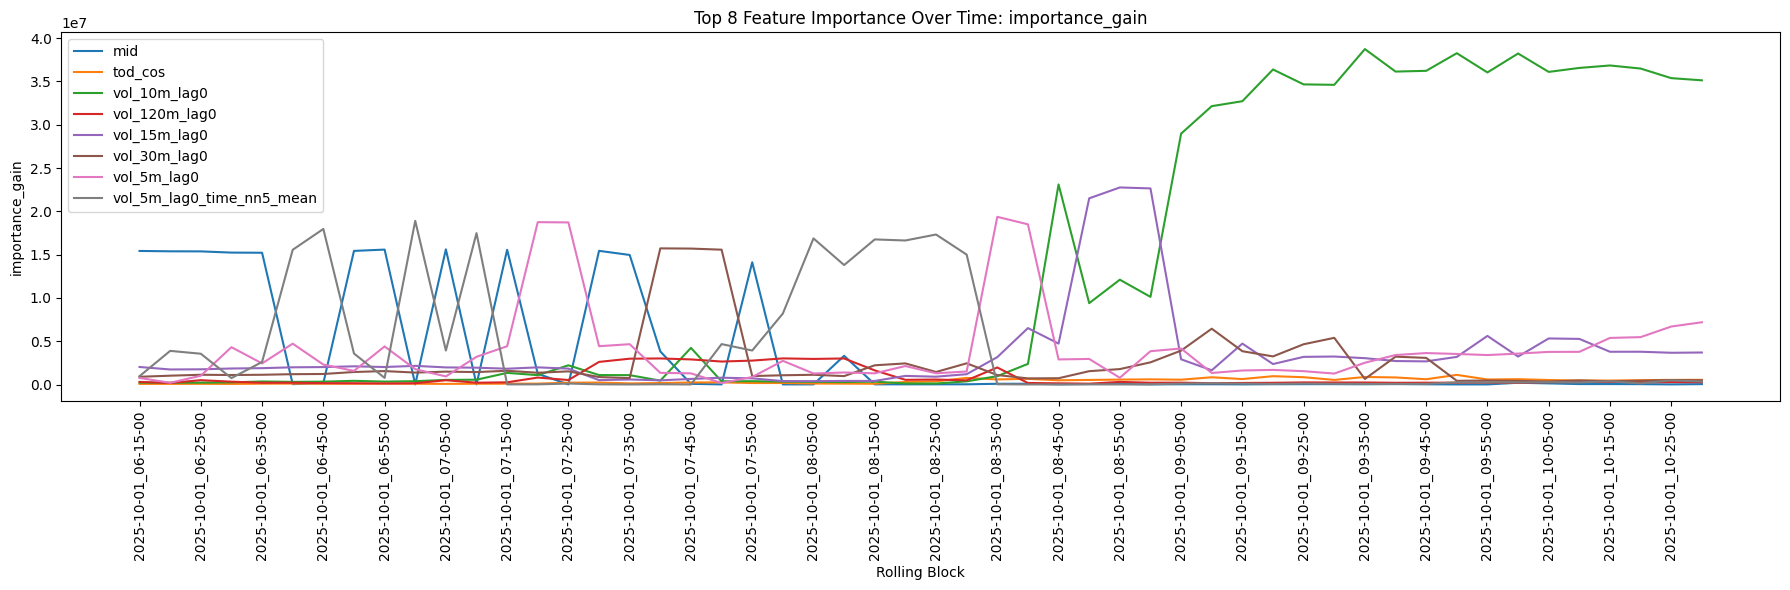

/home/liumingxuan/vol_prediction/Volatility_Prediction/analysis/tree_results_analysis.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.7072463768115942' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mat_plot.loc[idx] = (row - rmin) / (rmax - rmin)
/home/liumingxuan/vol_prediction/Volatility_Prediction/analysis/tree_results_analysis.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.691304347826087' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mat_plot.loc[idx] = (row - rmin) / (rmax - rmin)
/home/liumingxuan/vol_prediction/Volatility_Prediction/analysis/tree_results_analysis.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.60869565217391

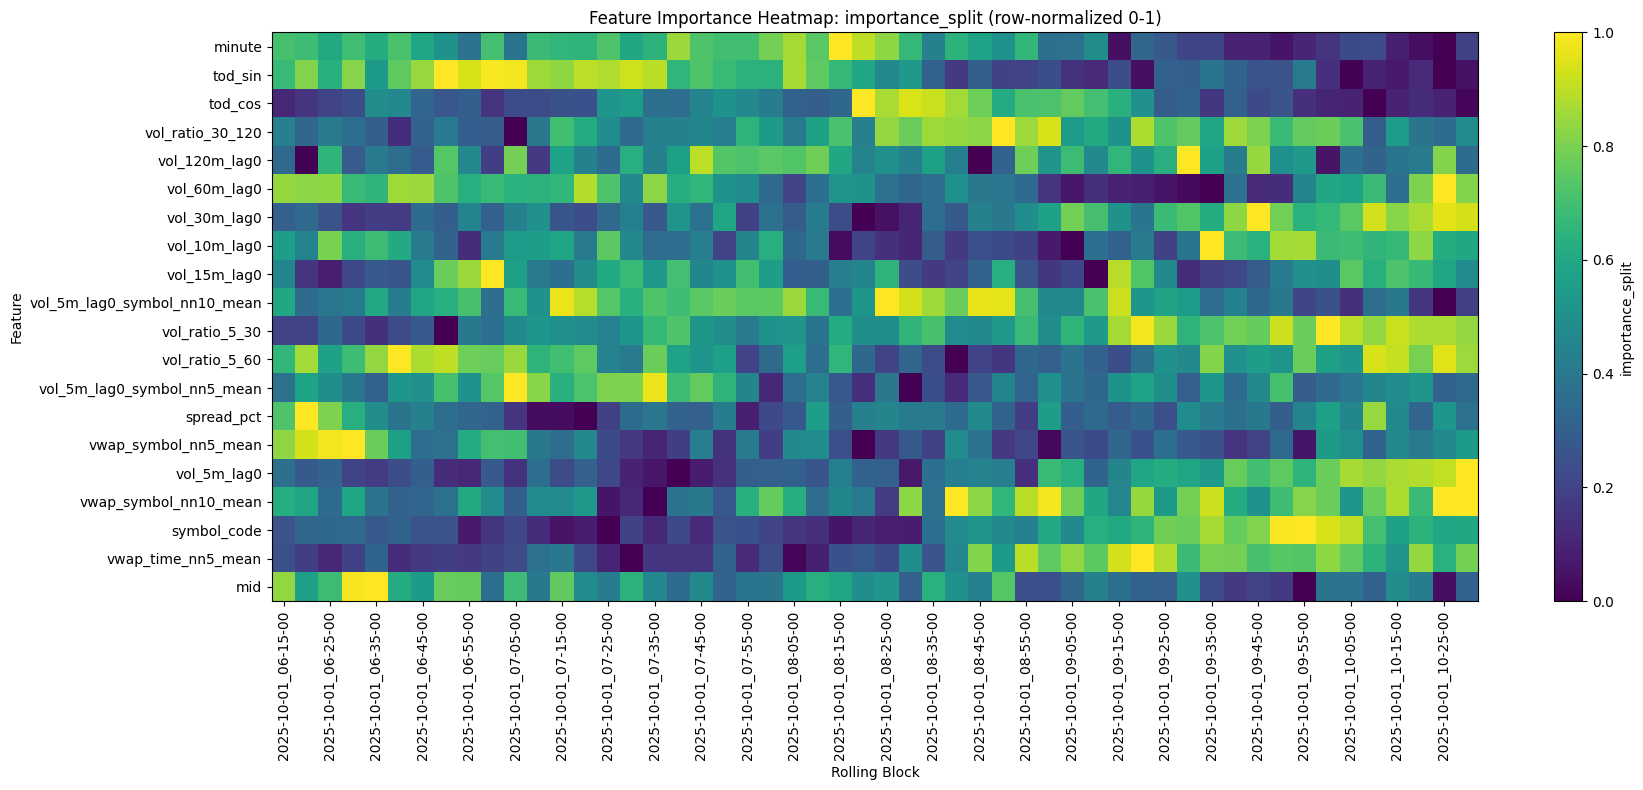

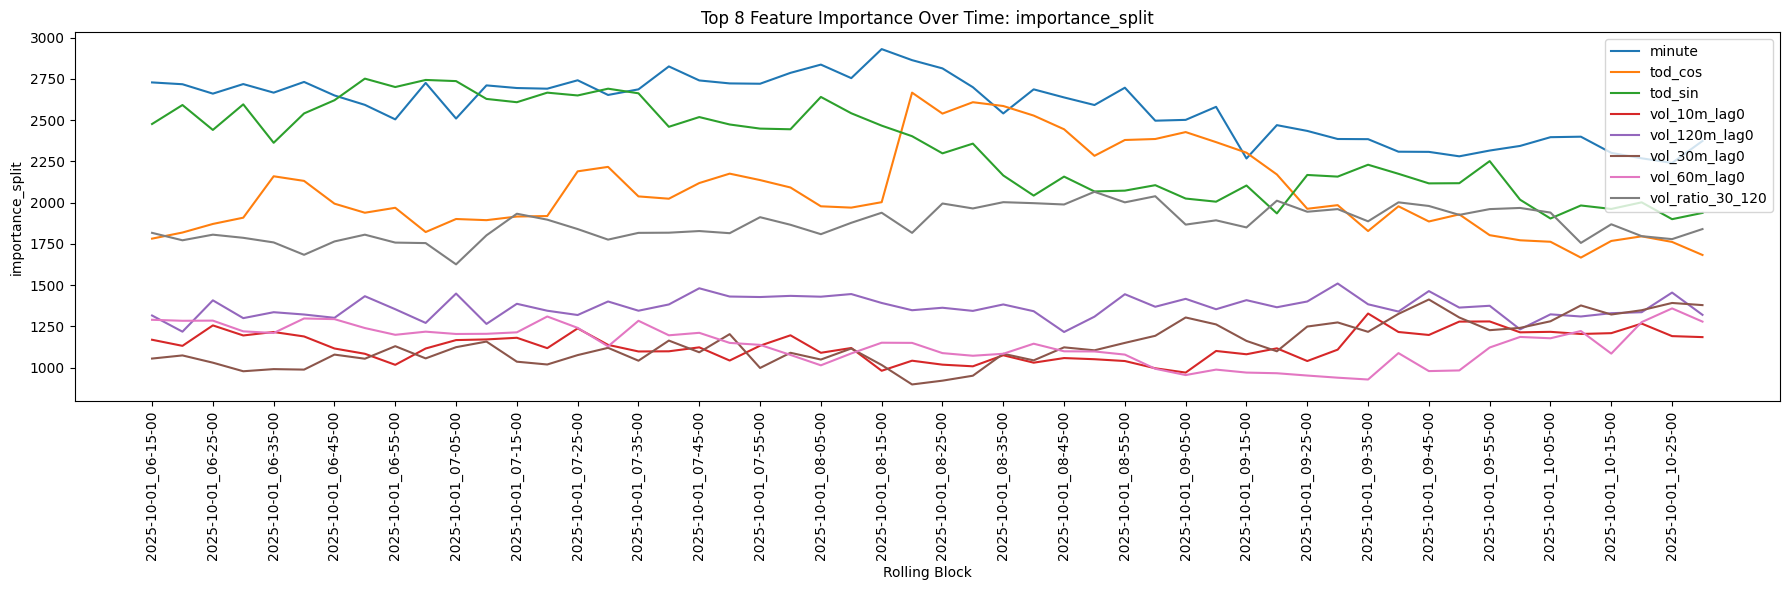

In [ ]:
imp_df = load_importance_blocks(IMPORTANCE_DIR)
feature_col, gain_col, split_col = detect_importance_columns(imp_df)

print("feature_col =", feature_col)
print("gain_col    =", gain_col)
print("split_col   =", split_col)

gain_mat = plot_importance_heatmap(
    imp_df=imp_df,
    value_col=gain_col,
    top_k=20,
    normalize_by_feature=True,
    figsize=(18, 8),
)

plot_feature_importance_lines(
    imp_df=imp_df,
    value_col=gain_col,
    top_k=8,
    figsize=(18, 6),
)

split_mat = plot_importance_heatmap(
    imp_df=imp_df,
    value_col=split_col,
    top_k=20,
    normalize_by_feature=True,
    figsize=(18, 8),
)

plot_feature_importance_lines(
    imp_df=imp_df,
    value_col=split_col,
    top_k=8,
    figsize=(18, 6),
)

#### 不同指标下 lgbm，regression，lag 对比


[y_true check] lgbm vs lag
匹配数量: 98
不匹配数量: 2
不匹配位置: [ 2 60]
lgbm: [1.5500911 1.8129706]
lag: [1.62564728 1.81656832]


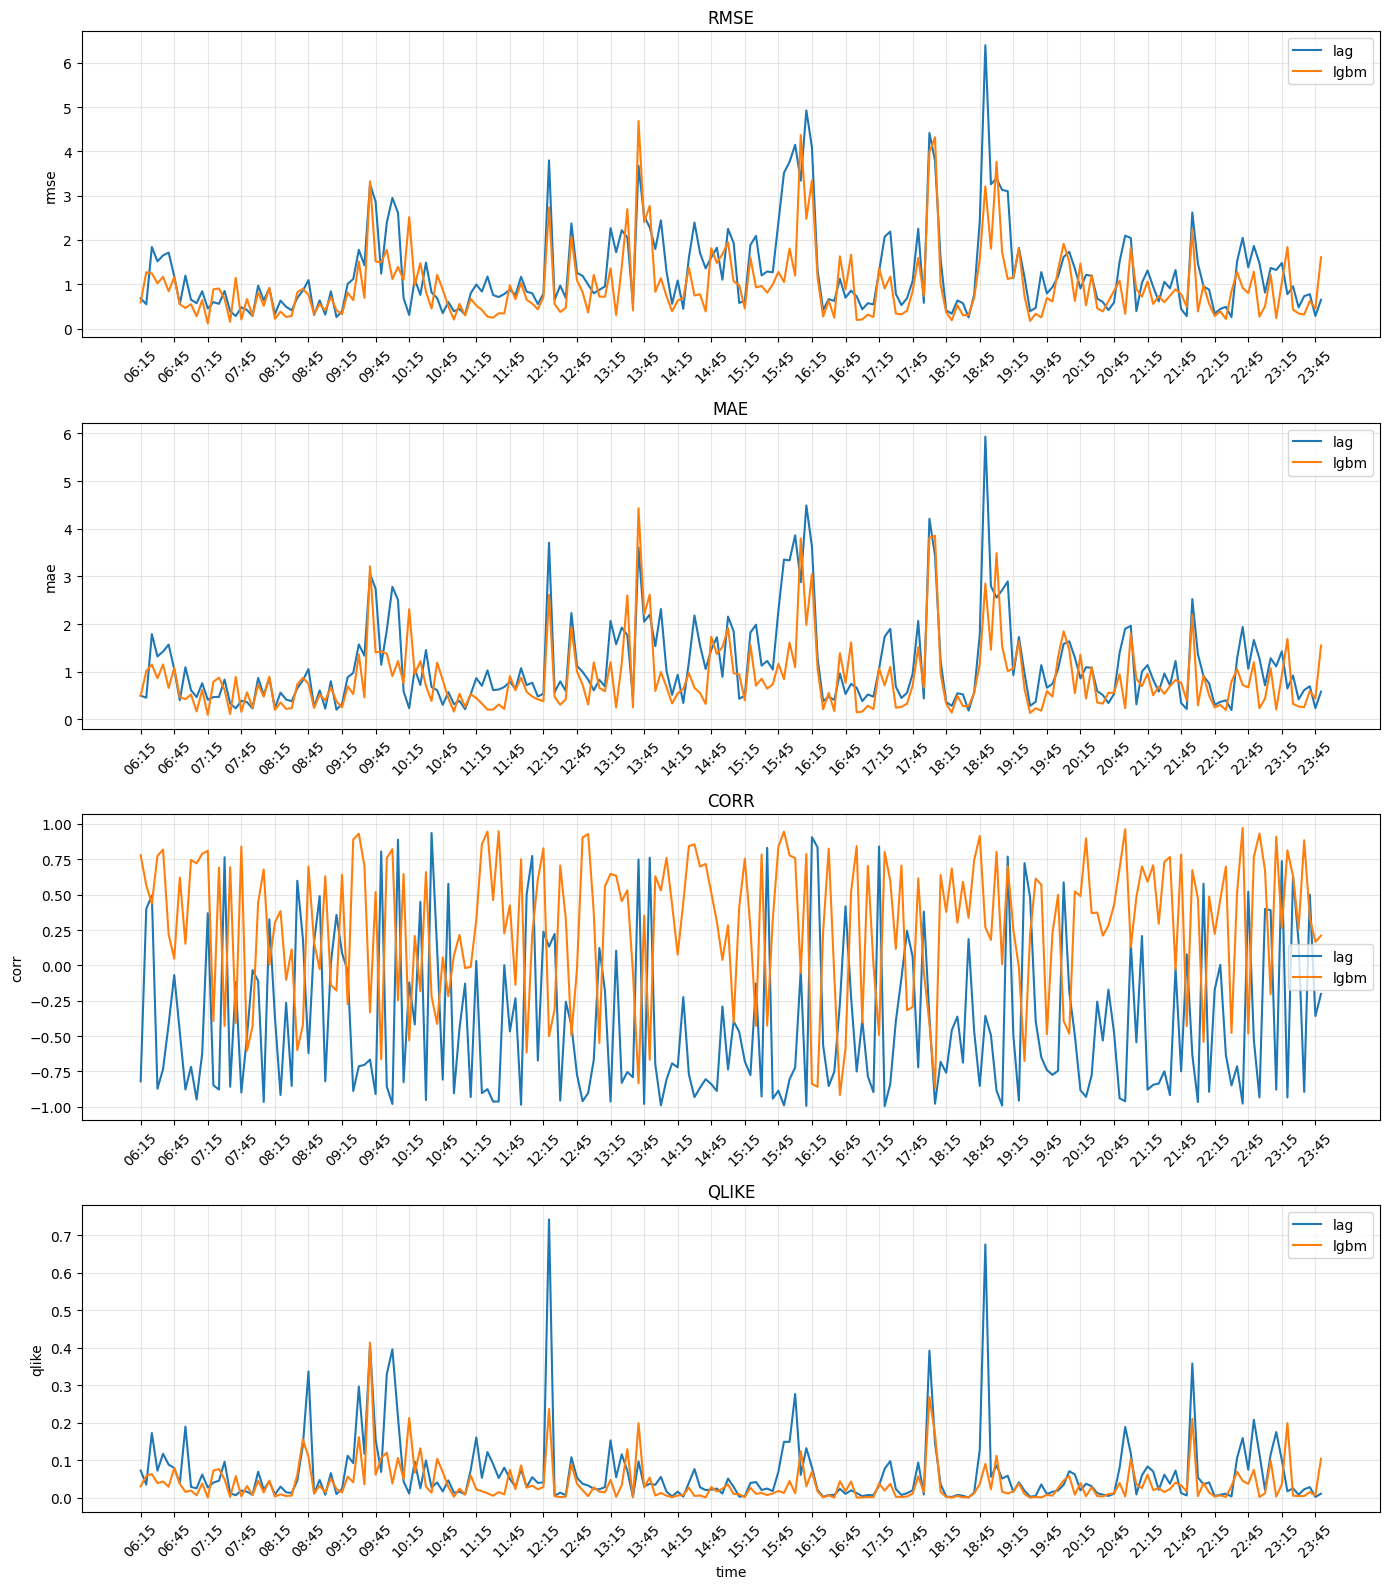

In [ ]:
df_1s_all = df_1s_all.reset_index(drop=True)
base_df = base_df.reset_index(drop=True)

data_dict = {
    "ts": df_1s_all["timestamp"][:-1],
    "models": {
        "lgbm": {
            "y_pred": df_1s_all["y_pred"][:-1],
            "y_true": df_1s_all["y_true"][:-1],
        },
        "lag": {
            "y_pred": base_df["lag_pred"],
            "y_true": base_df["y_true"],
        },
    }
}

plot_5min_metrics_from_dict(data_dict)


[y_true check] lgbm vs lr
匹配数量: 98
不匹配数量: 2
不匹配位置: [ 2 60]
lgbm: [1.5500911 1.8129706]
lr: [1.62564728 1.81656832]


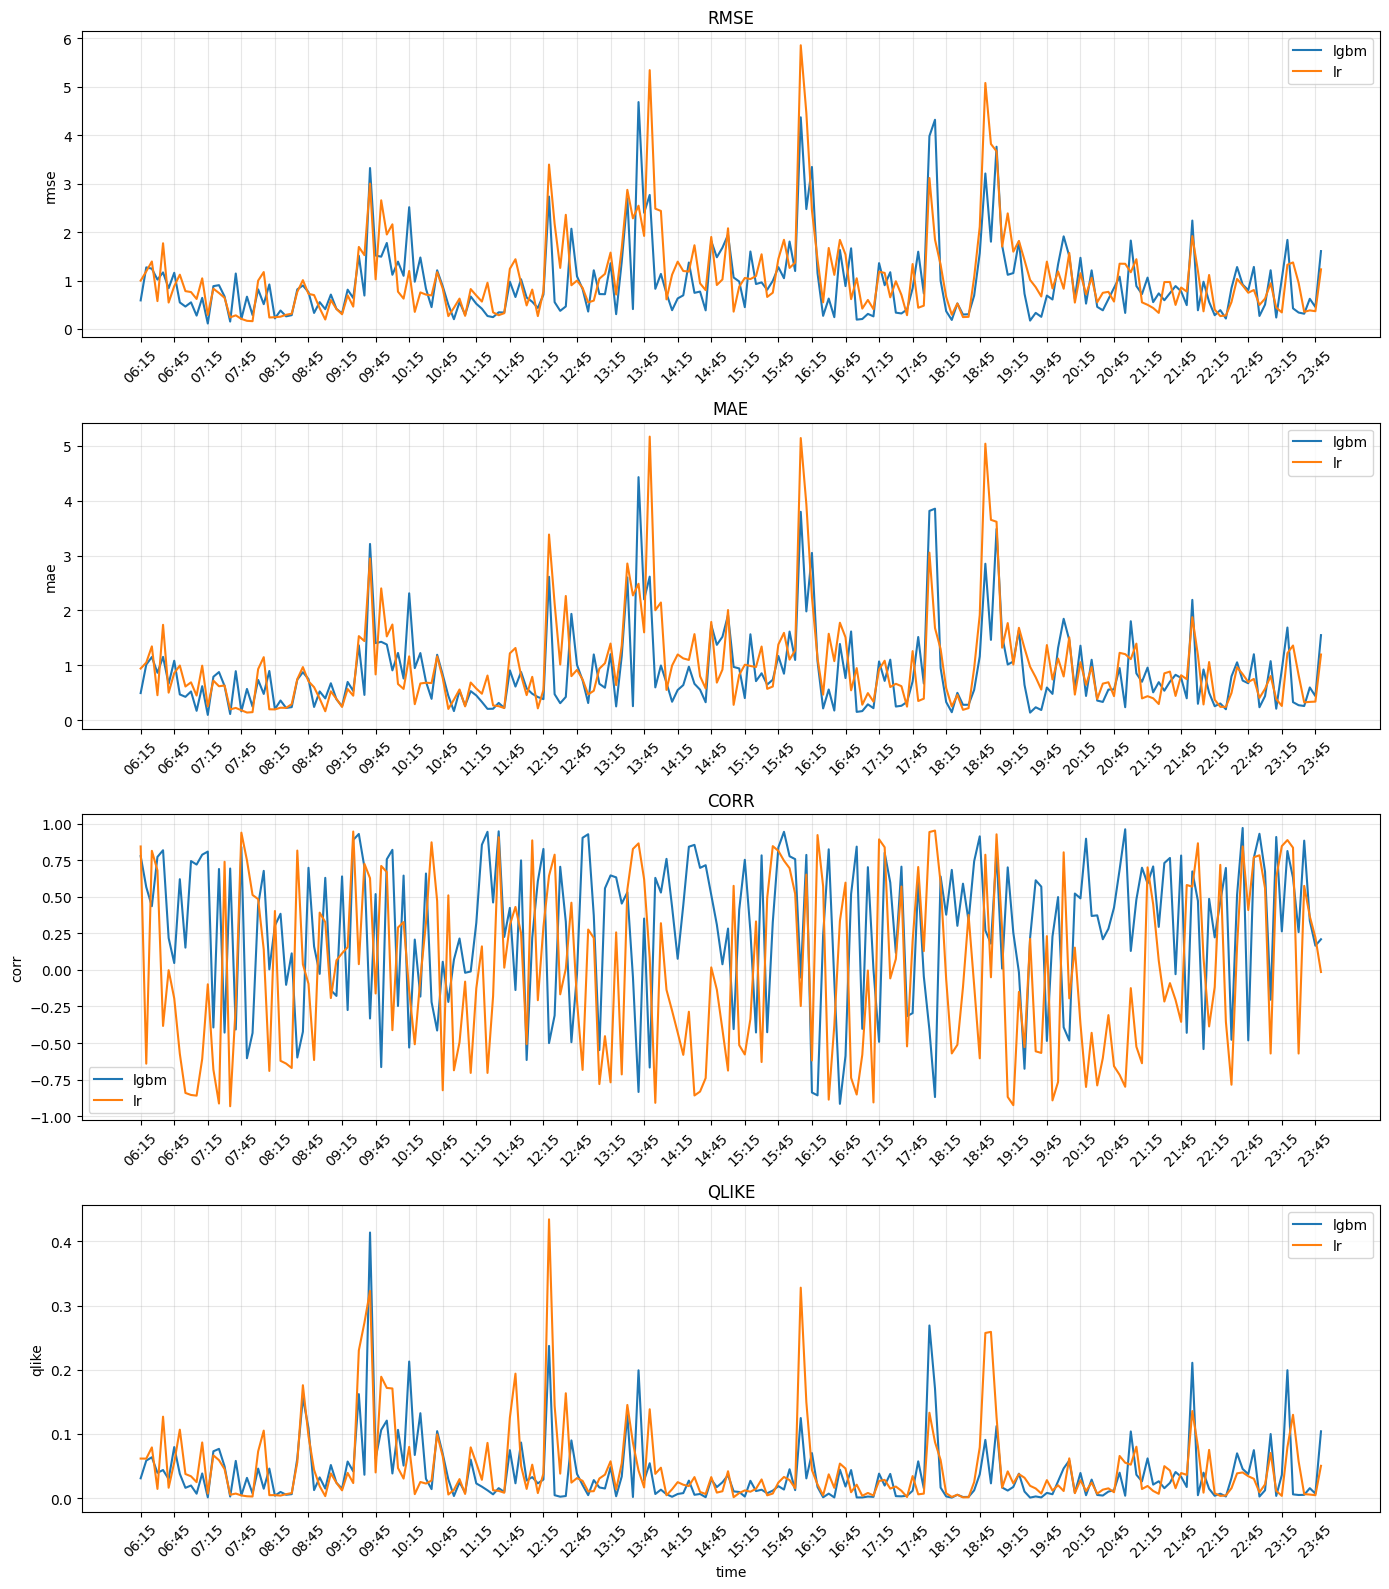

In [ ]:
df_1s_all = df_1s_all.reset_index(drop=True)
base_df = base_df.reset_index(drop=True)

data_dict = {
    "ts": df_1s_all["timestamp"][:-1],
    "models": {
        "lgbm": {
            "y_pred": df_1s_all["y_pred"][:-1],
            "y_true": df_1s_all["y_true"][:-1],
        },
        "lr": {
            "y_pred": base_df["y_pred"],
            "y_true": base_df["y_true"],
        }
    }
}

plot_5min_metrics_from_dict(data_dict)

#### y_true vs y_hat

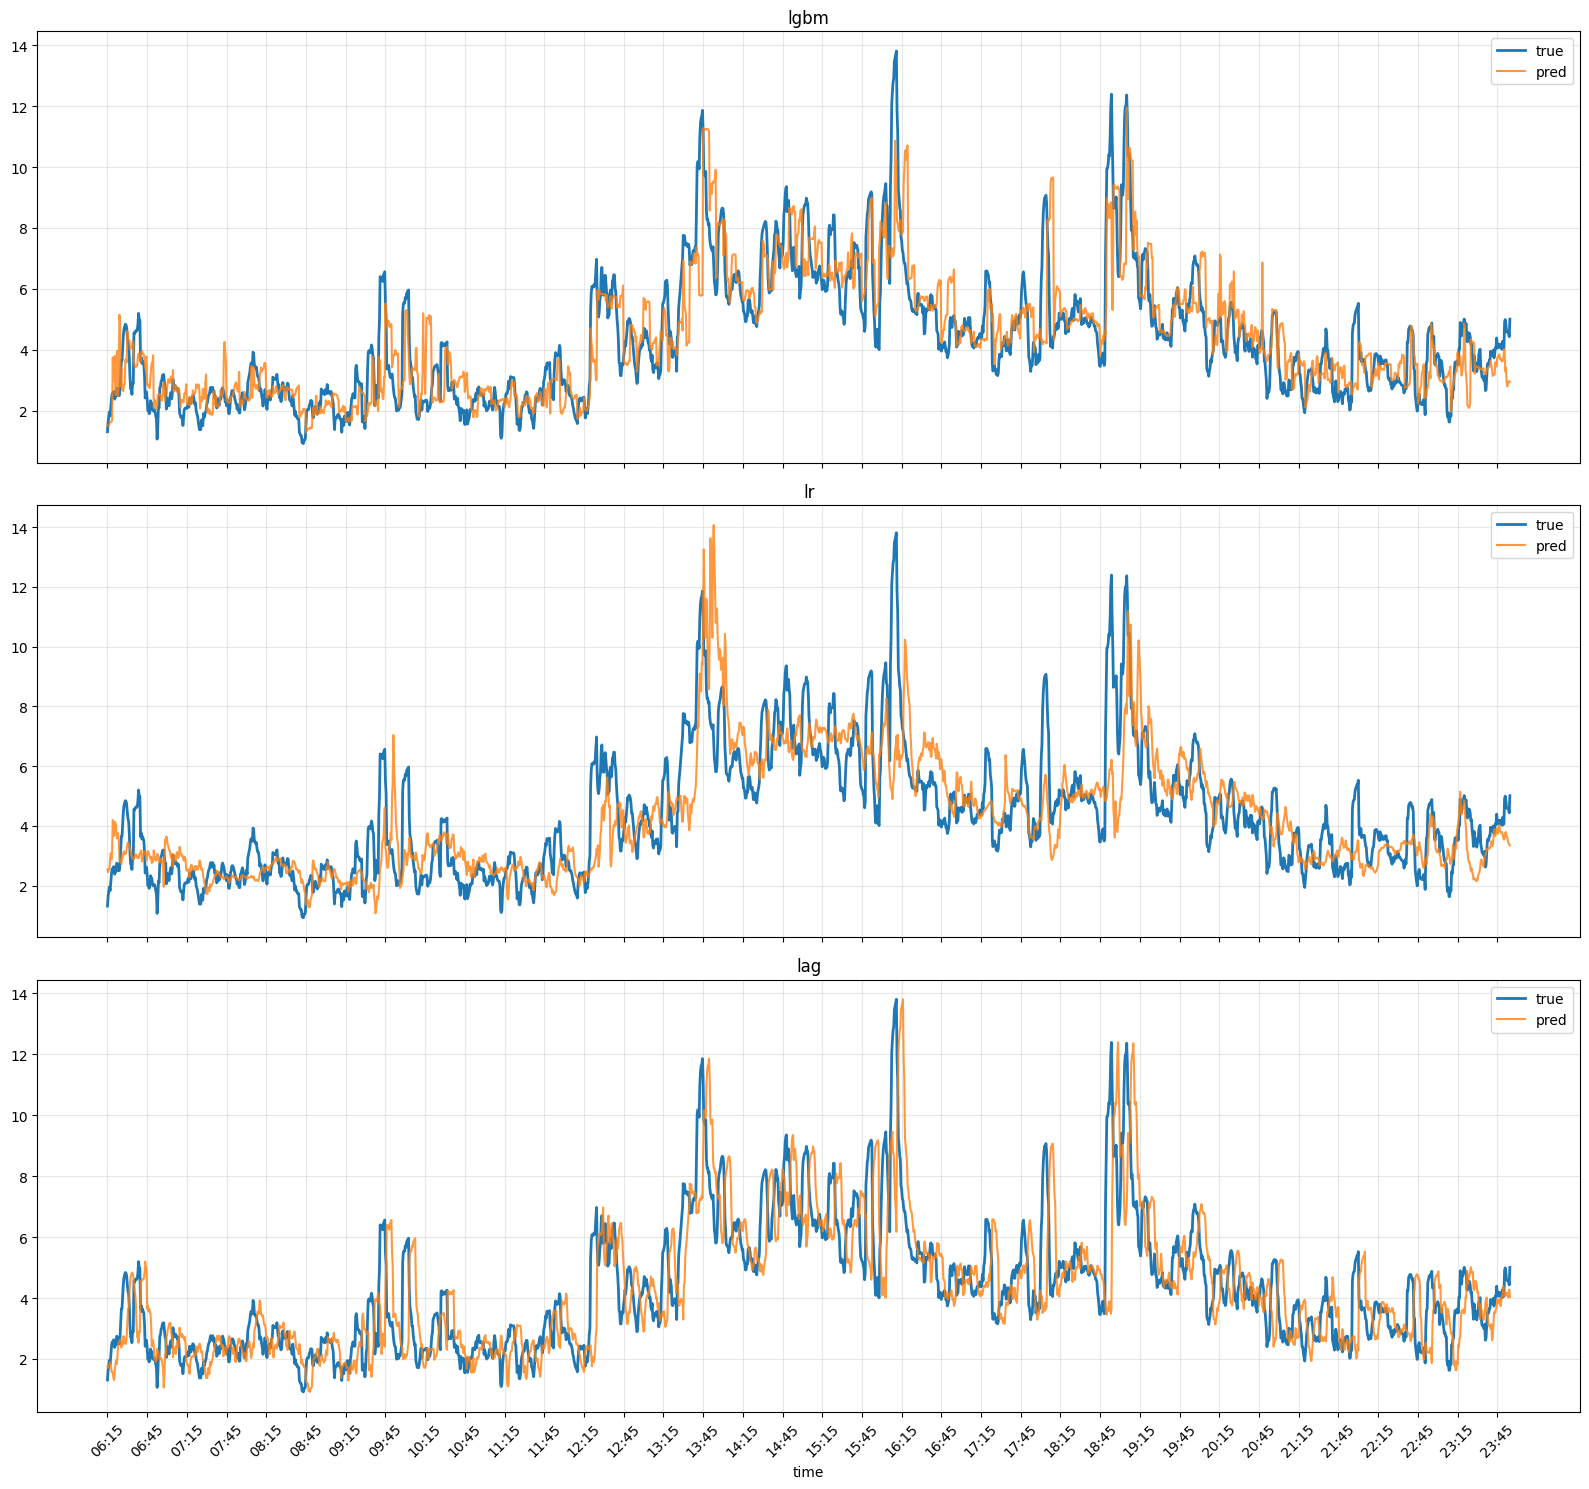

(<Figure size 1600x1500 with 3 Axes>,
 array([<Axes: title={'center': 'lgbm'}>, <Axes: title={'center': 'lr'}>,
        <Axes: title={'center': 'lag'}, xlabel='time'>], dtype=object))

In [16]:
model_dict = {
    "lgbm": {
        "y_pred": df_1s_all["y_pred"][:-1],
        "y_true": df_1s_all["y_true"][:-1],
    },
    "lr": {
        "y_pred": base_df["y_pred"],
        "y_true": base_df["y_true"],
    },
    "lag": {
        "y_pred": base_df["lag_pred"],
        "y_true": base_df["y_true"],
    },
}

plot_pred_vs_true_time(
    ts=df_1s_all["timestamp"][:-1],
    model_dict=model_dict,
    subsample="30s"
)

In [21]:
from analysis.evals import evaluate

lgbm_eval = evaluate(
    y_true=df_1s_all["y_true"][:-1],
    y_pred=df_1s_all["y_pred"][:-1]
)

lr_eval = evaluate(
    y_true=base_df["y_true"],
    y_pred=base_df["y_pred"]
)

lag_eval = evaluate(
    y_true=base_df["y_true"],
    y_pred=base_df["lag_pred"]
)

print("LGBM:")
print(lgbm_eval)
print("\nLR:")
print(lr_eval)
print("\nLag:")
print(lag_eval)

LGBM:
{'rmse': 1.2636373562870489, 'mae': 0.8751827872322354, 'corr': 0.8055409921059754, 'qlike': 0.16353143013113575, 'n': 63600}

LR:
{'rmse': 1.4112739843473803, 'mae': 0.9967879635472143, 'corr': 0.753716562251977, 'qlike': 0.21012959718673999, 'n': 63600}

Lag:
{'rmse': 1.6086972396265622, 'mae': 1.1374213040158976, 'corr': 0.7028993729808185, 'qlike': 0.313508174572018, 'n': 63600}


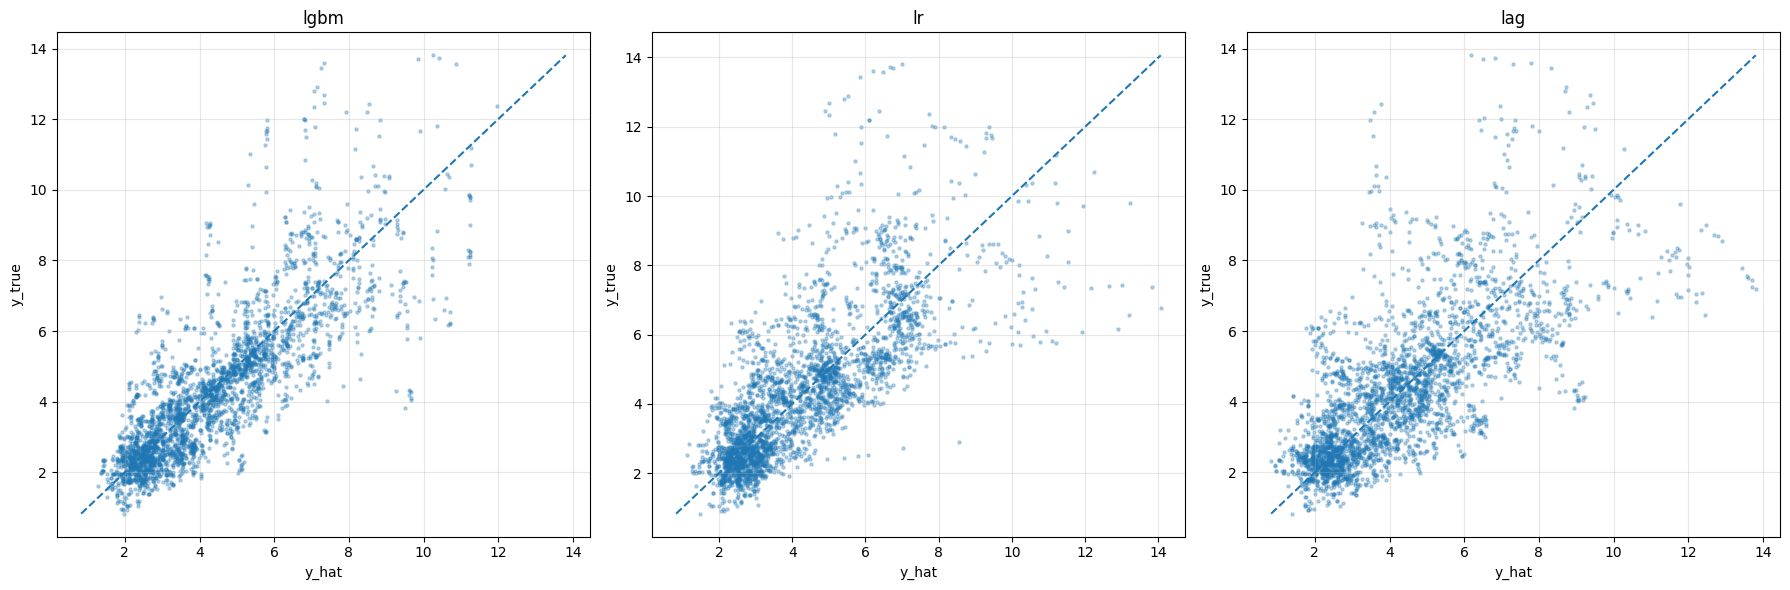

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'lgbm'}, xlabel='y_hat', ylabel='y_true'>,
        <Axes: title={'center': 'lr'}, xlabel='y_hat', ylabel='y_true'>,
        <Axes: title={'center': 'lag'}, xlabel='y_hat', ylabel='y_true'>],
       dtype=object))

In [23]:
model_dict = {
    "lgbm": {
        "y_pred": df_1s_all["y_pred"][:-1],
        "y_true": df_1s_all["y_true"][:-1],
    },
    "lr": {
        "y_pred": base_df["y_pred"],
        "y_true": base_df["y_true"],
    },
    "lag": {
        "y_pred": base_df["lag_pred"],
        "y_true": base_df["y_true"],
    },
}

plot_pred_true_scatter(
    model_dict,
    subsample=20
)